<a href="https://colab.research.google.com/github/parthsharma5575/Ai-Ml-GenAi/blob/main/ParthSharma_LLM_Day2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Encoder, Decoder & Parameters in Large Language Models (LLM)



**Instructions:** Answer all questions. Do not use AI-generated answers. Write clean, well-commented code where required.

## Question 1

Explain the difference between Encoder-only and Decoder-only architectures with a real-world example not discussed in class.

**Answer:**

Encoder-only architectures are concerned with the understanding and encoding of input text while decoder-only architectures are concerned with the generation of text token by token. The encoder-only architecture works by processing the input sequence entirely in both directions to generate contextual embeddings for classification or tagging purposes. On the other hand, the decoder-only architecture predicts the next token through autoregressive self-attention based on previous tokens.


Example from real world of encoder-only use case: Classification of customer reviews in e-commerce websites. An encoder-only network such as BERT receives as input the entire review text – “The product was delivered late, however the quality is top notch” and generates a contextual embedding which is later on classified as either “overall positive” or “mixed sentiment.”


Example from the real world of decoder-only use case: Email writing assistant. The decoder-only network such as the GPT generates an entire email starting from a short prompt “Write a professional email apologizing for the late delivery.” The sentences generated would be something like “I apologize for the inconvenience caused due to late delivery and appreciate your patience.”

## Question 2

Why is bidirectional context useful for text understanding? Give two NLP tasks where it is beneficial.

**Answer:**

The advantage of bidirectional context is that the meaning of a word is influenced by both its neighbors from the left and right. It may not be enough to look only in one direction since some information about the word will be lost, and its meaning would not be fully understood.

Some NLP applications where bidirectional context may be helpful are:

1. Named Entity Recognition, when knowledge of the words after the token allows classifying it into the group of personal names, organizations, and locations.

2. Sentiment analysis, when a positive word such as “great” may change its meaning depending on further words, for example, “great… except for the terrible service.”

## Question 3

Why can't a Decoder see future tokens during training? Explain with an example.

**Answer:**

The decoder in the language model cannot look ahead to the future tokens in training because the model is designed in such a way that the decoder predicts the next token based on previously seen tokens, and allowing the decoder to look ahead to the future tokens will make the task a cheating one instead of prediction. Masked causal attention forces the model to do so by setting the attention weights of the future tokens to be very negative, so that they are zero probability after softmax.


To illustrate, take the sentence “I live in Delhi.” For the task of predicting “Delhi,” the decoder can only look at “I live in,” but cannot look at the period or anything after “Delhi.” This is because the decoder will copy whatever it sees, which is easy but no learning takes place, if it looks ahead to the actual target token “Delhi” for predicting “Delhi.”

## Question 4

Compare BERT and GPT in terms of architecture, training objective, input visibility, and applications.

**Answer:**

BERT is an encoder-based architecture that makes use of bidirectional self-attention over the whole input sequence, while GPT is a decoder-based transformer that relies on causal language modeling with masked self-attention. The difference between BERT and GPT lies in the way how embeddings for tokens are built: BERT creates embeddings for all tokens at once, whereas GPT generates tokens sequentially based on previous tokens.


The objective function used for BERT's training is primarily the masked language model task (sometimes next sentence prediction) in which tokens are masked out and should be predicted, while GPT is trained with the causal language modeling objective in which the next token in the sequence is predicted.


In terms of input visibility, BERT sees the whole sequence at once in both directions, while GPT is not able to see future tokens due to causal masking. This leads to a wide-spread usage of BERT in understanding-related tasks (classification, NER, QA), while GPT is used in generation tasks (chatbots, code generation, story writing).

## Question 5

Draw the workflow of Encoder and Decoder using Mermaid or ASCII art.

**Answer:**

Encoder

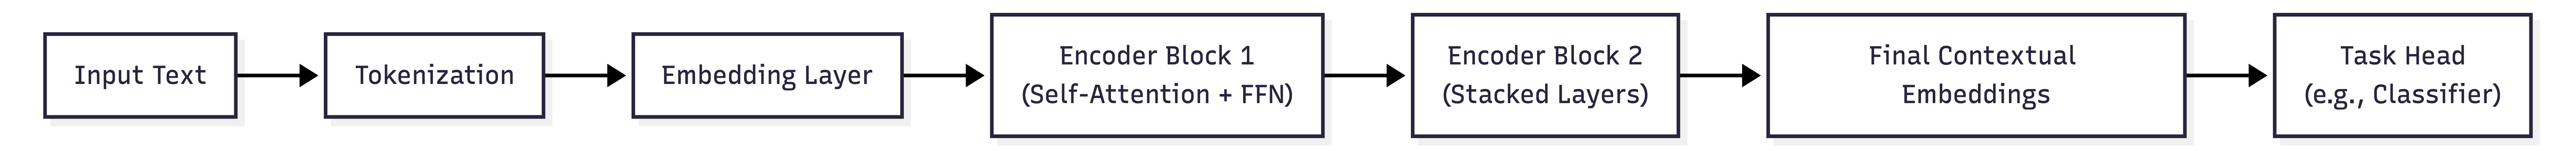

Decoder

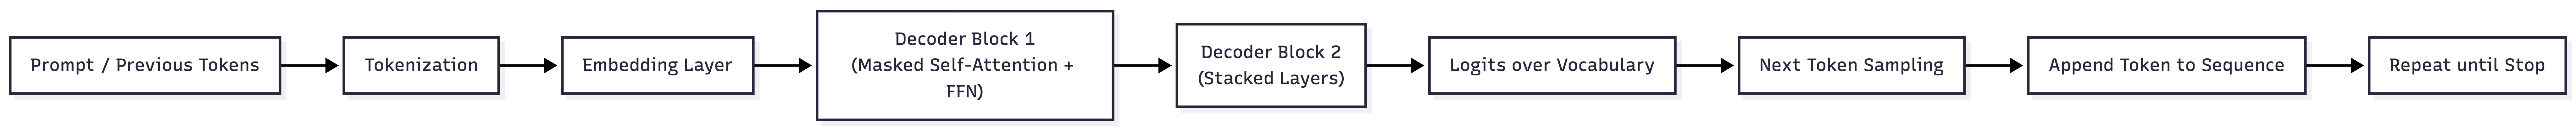

## Question 6

Predict which model (BERT or GPT) is better for: Sentiment Analysis, Chatbot, Text Summarization, Masked Word Prediction, Code Generation. Justify.

**Answer:**

**Sentiment analysis**-**BERT**-->
  *Uses bidirectional encoder-only architecture that captures full sentence context, which is ideal for classification tasks like sentiment.*


**Chatbot**-**GPT**--> *Decoder-only GPT excels at autoregressive text generation and is designed for conversational, open-ended responses.*



**Text** **Summarization**-**GPT** --> *Summarization naturally fits encoder–decoder models like T5 or BART, but GPT can produce abstractive summaries via generation, while BERT is mainly an encoder.*



**Masked Word Prediction**-**BERT** --> *BERT’s masked language modeling objective directly trains it to fill in masked tokens within a sentence.*



**Code-GPT** -->*Modern code LLMs are typically decoder-only GPT-style models trained on large code corpora for next-token generation.*


## Question 7

What is Masked Self-Attention? Explain why it prevents cheating.

**Answer:**

Masked self-attention is a form of self-attention where attention mask is used such that each position in the sequence can attend only to certain positions, generally not to future positions in a causal language model. The mechanism of masking in decoder-only LLMs is achieved by assigning attention weights of future tokens with extremely negative values prior to applying the softmax function.

This approach ensures no cheating happens as, during training, the network is required to predict the next token based on just previous tokens in the sequence, but not on the actual future tokens in the ground truth sequence. In case of non-masked self-attention, the model will be able to attend to the target token and thus simply memorize it without learning anything.

## Question 8

Differentiate Parameters, Weights, and Biases with examples.

**Answer:**

Parameters are the learnable numerical values in a model that are updated during training; they include both weights and biases. Weights are parameters that scale inputs in linear layers or attention projections, while biases are additive offsets applied after the weighted sum.

For example, in a simple linear layer
**𝑦=𝑊𝑥+𝑏**
the matrix **𝑊** contains weights that determine how each input feature contributes to each output feature. The vector **𝑏** is the bias term that shifts the output, allowing the model to fit data that does not pass through the origin. In a large language model, parameters include all such weights and biases across embedding layers, attention projections (query, key, value), feedforward networks, and output heads.

## Question 9

If a model has 15 billion parameters stored in FP16, estimate the memory required.

**Answer:**

FP16 (16-bit floating point) uses 2 bytes per parameter. With 15 billion parameters, the raw parameter memory can be estimated as:
**Memory=15000000000×2 bytes=30000000000 bytes**

This is 30 GB of memory, since
1 GB ≈ 10^9
  bytes in common usage. In practice, additional memory is needed for optimizer states, activations, and gradients, but the bare parameter storage for a 15B FP16 model is about 30 GB.

## Question 10

Estimate memory for a 70B parameter model in FP32.

**Answer:**

FP32 (32-bit floating point) uses 4 bytes per parameter. For 70 billion parameters, the raw memory requirement is:

**Memory=70000000000×4 bytes=280000000000 bytes**

This is approximately 280 GB of memory for the parameters alone. Again, real training or inference might require more memory due to activations, gradients, and optimizer states, but the core FP32 parameter storage for a 70B model is around 280 GB.

## Question 11

Write Python code using transformers pipeline to perform a fill-mask task.

**Answer:**

In [26]:
from transformers import pipeline

# Initialize a fill-mask pipeline with a BERT-style model
fill_mask = pipeline(
    "fill-mask",
    model="bert-base-uncased",
    tokenizer="bert-base-uncased"
)

# Example sentence with a [MASK] token
text = "I love visiting [MASK] in the winter."

# Run the fill-mask pipeline
outputs = fill_mask(text)

# Display the top predictions
for i, o in enumerate(outputs, start=1):
    print(f"{i}. Token: {o['token_str']}\n score: {o['score']:.4f}\n prediction: {o['sequence']}\n\n")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


1. Token: you
 score: 0.2757
 prediction: i love visiting you in the winter.


2. Token: her
 score: 0.1683
 prediction: i love visiting her in the winter.


3. Token: him
 score: 0.1248
 prediction: i love visiting him in the winter.


4. Token: them
 score: 0.1131
 prediction: i love visiting them in the winter.


5. Token: here
 score: 0.0329
 prediction: i love visiting here in the winter.




## Question 12

Write Python code using GPT-2 to generate text from a prompt.

**Answer:**

In [27]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load tokenizer and model for GPT-2
generator = pipeline("text-generation", model="gpt2")

# Define a prompt
prompt = "On a rainy evening in Delhi, I decided to"

result = generator(
    prompt,
    max_length=50,
    num_return_sequences=1
)
print(result[0]['generated_text'])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


On a rainy evening in Delhi, I decided to go to the park to see it.

I was surprised and surprised to find that this park is just about every park with its own unique story. I'm sure there are thousands of other unique stories out there.

I'm sure there are many others like this.

It's hard to pick just one of them.

When I first started to read about this park, I was a little hesitant to put the full story into a blog.

In the end, I decided to share the story of this beautiful park with the world.

I feel I'm giving people the world's first true story about the iconic park.

For the first time in my life, I can see the real life effects of this park.

There is still a lot to learn about this amazing place.

It's not only for the people here, but for the environment.

It's just so unique.

It's so peaceful, it's so beautiful.

I think it reminds me of the beauty of nature.

It's like the most amazing thing you can imagine.

It's the place that feels like home.

The beauty of nature.



## Question 14

Research Question: Compare Encoder-only, Decoder-only and Encoder-Decoder architectures in a table.

**Answer:**

| Aspect            | Encoder-only                                                                   | Decoder-only                                                            | Encoder–Decoder                                                                                                               |
| ----------------- | ------------------------------------------------------------------------------ | ----------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------- |
| Core idea         | Encode input into contextual representations. aiml+1                           | Autoregressively generate tokens from past context. mbottoni.github+1   | Map input sequence to output sequence via separate encoder and decoder. aiml+2                                                |
| Attention pattern | Bidirectional self-attention over full input. mbottoni.github+1                | Masked (causal) self-attention over past tokens only. mbottoni.github+1 | Encoder uses bidirectional self-attention; decoder uses masked self-attention plus cross-attention to encoder outputs. aiml+2 |
| Typical models    | BERT, RoBERTa, DistilBERT. mbottoni.github+1                                   | GPT, LLaMA, many chat/code LLMs. linkedin+1                             | T5, BART, original Transformer for translation. aiml+2                                                                        |
| Strengths         | Strong at understanding, classification, token-level labeling. aiml+1          | Strong at free-form generation, completion, dialogue, code. aiml+2      | Strong at tasks that transform one sequence into another (translation, summarization, QA). aiml+2                             |
| Typical tasks     | Sentiment analysis, NER, semantic similarity, extractive QA. mbottoni.github+1 | Chatbots, story writing, code generation, language modeling. aiml+2     | Machine translation, abstractive summarization, style transfer, seq2seq QA. aiml+2                                            |

## Question 15

Debug: Find and fix five possible issues in the provided BERT/GPT implementation (internet, package, model name, memory, token).

**Answer:**

Since the exact buggy code is not shown in the notebook content I have, I will describe five common issues and how I would fix them in a typical BERT/GPT Colab implementation.

Internet / model download issue:

Problem: Colab runtime has no internet or restricted access, causing from_pretrained calls to fail when downloading models.

Fix: Ensure runtime has internet enabled, or switch to a locally available model checkpoint, or mount Google Drive and load the model from a saved directory.

Package version mismatch (transformers / torch):

Problem: Using an outdated or incompatible transformers version with the installed torch can cause import or runtime errors.

Fix: Install a compatible version, for example:

python
!pip install -U transformers torch
and restart the runtime to ensure consistent versions.

Incorrect model name:

Problem: Typos like "bert_base_uncased" instead of "bert-base-uncased" or wrong GPT model identifiers break from_pretrained.

Fix: Use verified model names from the Hugging Face Hub, such as "bert-base-uncased" for BERT and "gpt2" for GPT-2.

Memory issues (batch size / sequence length):

Problem: Setting very large batch sizes or sequence lengths causes CUDA out-of-memory errors when running BERT or GPT on Colab GPUs.

Fix: Reduce batch size, sequence length, or use gradient accumulation; optionally switch to smaller models like distilbert-base-uncased or gpt2-medium instead of larger variants.

Token / special token handling:

Problem: For BERT, forgetting to use [CLS] and [SEP] or mismatched mask tokens ([MASK] vs <mask> for different models) leads to incorrect behavior.

Fix: Use the tokenizer’s built-in special tokens (e.g., tokenizer.mask_token, tokenizer.cls_token, tokenizer.sep_token) and rely on tokenizer.encode or tokenizer(___, return_tensors="pt") instead of manually inserting strings.

## Question 17

Interview Q1: Why do larger parameter counts not always produce better performance?

**Answer:**

Larger parameter counts do not always yield better performance because simply increasing model size can lead to overfitting, optimization difficulties, or inefficient use of data if the training corpus and training strategy are not scaled appropriately. Big models need more high-quality data, careful regularization, and sufficient compute; without these, they may memorize noise instead of learning generalizable patterns.

Additionally, some tasks saturate in performance at moderate model sizes, so extra parameters bring diminishing returns relative to their computational cost. Factors like architecture choice, pretraining objective, fine-tuning setup, and evaluation metrics all influence real-world performance more than parameter count alone.

## Question 18

Interview Q2: What happens if model weights are randomly initialized and never trained?

**Answer:**

If a model’s weights are randomly initialized and never trained, the model will essentially produce random outputs that do not capture meaningful relationships in the data. In a language model, this means predictions of next tokens or classifications will be close to random guessing with no coherent structure or understanding.

Training adjusts weights and biases so that the model’s internal representations align with patterns in the dataset, reducing loss and improving accuracy. Without this process, the parameters remain arbitrary, and the model behaves like a complex but uncalibrated function, unable to generalize or solve NLP tasks reliably.

## Question 20

Mini Project: Build a notebook demonstrating BERT fill-mask and GPT text generation, compare outputs, limitations, runtime, and conclusions.

**Answer:**

In [28]:
import time
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

In [29]:
fill_mask = pipeline(
    "fill-mask",
    model="bert-base-uncased",
    tokenizer="bert-base-uncased"
)


text="The capital of China is [MASK]."

bert_results = []

print("=== BERT Results ===")
start = time.time()

output = fill_mask(text)
end = time.time()

print("BERT Predictions:\n")

for i in output:
    print("Word :", i["token_str"])
    print("Score:", round(i["score"],4))
    print("Sentence:", i["sequence"])
    print()

bert_time = end-start

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


=== BERT Results ===
BERT Predictions:

Word : beijing
Score: 0.5411
Sentence: the capital of china is beijing.

Word : nanjing
Score: 0.148
Sentence: the capital of china is nanjing.

Word : shanghai
Score: 0.0708
Sentence: the capital of china is shanghai.

Word : guangzhou
Score: 0.0576
Sentence: the capital of china is guangzhou.

Word : shenzhen
Score: 0.0455
Sentence: the capital of china is shenzhen.



In [30]:
# === GPT-2 Text Generation ===
generator = pipeline(
    "text-generation",
    model="gpt2"
)

prompt = "China as a country is "

start = time.time()

output = generator(
    prompt,
    max_length=50,
    num_return_sequences=1
)

end = time.time()

print(output[0]["generated_text"])

gpt_time = end-start

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


China as a country is  to become an  an  Aryan nation.  As an  Aryan nation,  it is  to become  a  Aryan nation  (as the English call it).  According to the history of the "Aryan Nation",  it has been the  world's most populous nation.  Since the beginning of time,  it has been the  America  nation.  It has been the  America  nation for three  and a half centuries.  Its  population is less than 100,000.  In fact,  it  has been the  world's  largest  Jew.  One of the most important  questions that  is asked of  America at a  religious  conversation is  whether  America  is the  United States  (that is,  it is the  United States  nation).  The Aryan  Nation  is  the  United States  nation.  It is  the  United States  nation because


In [31]:
# === Comparison and Conclusions ===

print("=== Comparison ===")
print("BERT (encoder-only) performs fill-mask by using full sentence context to predict a missing word.")
print("GPT-2 (decoder-only) generates full continuations from a prompt, one token at a time.")

print("\nRuntime (approx):")
print(f"BERT runtime: {bert_time:.2f} seconds")
print(f"GPT-2 runtime: {gpt_time:.2f} seconds")

print("\nLimitations:")
print("- BERT: Great at understanding and masked word prediction, but not designed for long free-form generation.")
print("- GPT-2: Great at generation, but can hallucinate facts and is sensitive to prompt wording.")

print("\nConclusions:")
print("BERT is better suited for understanding-oriented tasks like fill-mask and classification.")
print("GPT-2 is better suited for open-ended text generation such as stories or continuations.")
print("This mini project shows how encoder-only and decoder-only architectures behave differently on real NLP tasks.")

=== Comparison ===
BERT (encoder-only) performs fill-mask by using full sentence context to predict a missing word.
GPT-2 (decoder-only) generates full continuations from a prompt, one token at a time.

Runtime (approx):
BERT runtime: 0.13 seconds
GPT-2 runtime: 17.62 seconds

Limitations:
- BERT: Great at understanding and masked word prediction, but not designed for long free-form generation.
- GPT-2: Great at generation, but can hallucinate facts and is sensitive to prompt wording.

Conclusions:
BERT is better suited for understanding-oriented tasks like fill-mask and classification.
GPT-2 is better suited for open-ended text generation such as stories or continuations.
This mini project shows how encoder-only and decoder-only architectures behave differently on real NLP tasks.
